# Chapter 7 Lab: Front, Middle, and Back Office Applications

**Runtime:** 3–4 minutes · **Difficulty:** intermediate · **Credentials:** none

A single "LLM accuracy" number cannot govern three different workflows. This notebook
builds one compact case for each office: earnings tone, covenant monitoring, and AML
investigation triage. Each receives task-specific metrics and a common release record.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/07_finance_applications.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/07_finance_applications.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- match metrics to financial workflow costs;
- distinguish research signals from control decisions;
- evaluate extraction and numerical checks separately;
- build a temporal AML baseline; and
- compare applications with a common governance scorecard.


In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab.documents import covenant_checks, extract_contract_terms
from finllm_lab.metrics import proportion_interval
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.temporal import chronological_split

set_finance_theme()


## 1. Front office: management-tone research

A chronological TF–IDF classifier is the transparent baseline. Label-revealing template
language is neutralized first. The output informs research prioritization; it does not
authorize a trade.


In [3]:
calls = pd.read_csv(ROOT / "data" / "earnings_calls.csv", parse_dates=["available_at"])
calls = calls.sort_values("available_at").reset_index(drop=True)
tone_phrases = [
    "Management described demand as resilient and execution as strong.",
    "Management cited softer demand, execution pressure, and elevated uncertainty.",
    "Management described conditions as mixed and maintained a balanced outlook.",
]
calls["model_text"] = calls["text"]
for phrase in tone_phrases:
    calls["model_text"] = calls["model_text"].str.replace(
        phrase,
        "Management discussed execution, demand, and uncertainty.",
        regex=False,
    )
front_split = chronological_split(
    calls["available_at"],
    train_fraction=0.65,
    validation_fraction=0.15,
)
front_train, front_test = calls.iloc[front_split.train], calls.iloc[front_split.test]
front_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=2500)),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=707,
            ),
        ),
    ]
)
front_model.fit(front_train["model_text"], front_train["sentiment_label"])
front_test = front_test.copy()
front_test["prediction"] = front_model.predict(front_test["model_text"])
front_labels = sorted(calls["sentiment_label"].unique())
front_correct = int(
    (front_test["prediction"] == front_test["sentiment_label"]).sum()
)
front_accuracy, front_accuracy_low, front_accuracy_high = proportion_interval(
    front_correct,
    len(front_test),
)
front_metrics = {
    "macro_f1": f1_score(
        front_test["sentiment_label"],
        front_test["prediction"],
        labels=front_labels,
        average="macro",
        zero_division=0,
    ),
    "accuracy": front_accuracy,
    "accuracy_wilson_low": front_accuracy_low,
    "accuracy_wilson_high": front_accuracy_high,
    "evidence_link_rate": float(front_test["document_id"].notna().mean()),
    "trade_authority": 0.0,
}
pd.DataFrame([front_metrics], index=["front_office"]).round(3)


,macro_f1,accuracy,accuracy_wilson_low,accuracy_wilson_high,evidence_link_rate,trade_authority
front_office,0.326,0.529,0.31,0.738,1.0,0.0


## 2. Middle office: covenant monitoring


In [4]:
contracts = [json.loads(line) for line in (ROOT / "data" / "contracts.jsonl").read_text().splitlines()]
middle_rows = []
for contract in contracts:
    terms = extract_contract_terms(contract["text"])
    required_terms = {
        "facility_amount_mn",
        "maturity_years",
        "spread_bps",
        "max_leverage",
        "min_coverage",
        "currency",
    }
    checks = covenant_checks(
        terms,
        leverage=contract["observed_leverage"],
        interest_coverage=contract["observed_interest_coverage"],
    )
    middle_rows.append(
        {
            "ticker": contract["ticker"],
            "term_completeness": len(required_terms & set(terms)) / len(required_terms),
            "currency_conflict": "currency_conflict" in terms,
            "covenants": len(checks),
            "breaches": sum(not check.compliant for check in checks),
            "minimum_headroom": min(check.headroom for check in checks),
            "status": "escalate" if any(not check.compliant for check in checks) else "clear",
        }
    )
middle = pd.DataFrame(middle_rows)
middle


,ticker,term_completeness,currency_conflict,covenants,breaches,minimum_headroom,status
0,ACME,1.0,False,2,0,0.32,clear
1,NIMB,1.0,False,2,1,-0.14,escalate
2,ORBT,1.0,False,2,0,0.34,clear
3,VELA,1.0,False,2,1,-0.11,escalate


## 3. Back office: temporal AML triage

The model prioritizes investigations. Recall matters because missed suspicious cases are
costly; precision matters because every false alert consumes investigator capacity.


In [5]:
transactions = pd.read_csv(ROOT / "data" / "transactions.csv", parse_dates=["timestamp"])
transactions = transactions.sort_values("timestamp").reset_index(drop=True)
features = [
    "amount_usd",
    "cross_border",
    "new_beneficiary",
    "cash_equivalent",
    "country_risk",
    "velocity_24h",
    "night_transaction",
]
split = chronological_split(transactions["timestamp"], train_fraction=0.70, validation_fraction=0.10)
train = transactions.iloc[split.train]
validation = transactions.iloc[split.validation]
test = transactions.iloc[split.test]
aml_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=707),
)
aml_model.fit(train[features], train["investigation_label"])
validation_probability = aml_model.predict_proba(validation[features])[:, 1]
threshold_candidates = []
for candidate in np.linspace(0.05, 0.95, 91):
    candidate_prediction = (validation_probability >= candidate).astype(int)
    threshold_candidates.append(
        {
            "threshold": candidate,
            "recall": recall_score(
                validation["investigation_label"],
                candidate_prediction,
                zero_division=0,
            ),
            "precision": precision_score(
                validation["investigation_label"],
                candidate_prediction,
                zero_division=0,
            ),
            "alert_rate": candidate_prediction.mean(),
        }
    )
threshold_search = pd.DataFrame(threshold_candidates)
within_capacity = threshold_search[threshold_search["alert_rate"] <= 0.15]
if within_capacity.empty:
    raise RuntimeError("No validation threshold satisfies the declared alert-capacity budget")
selected_threshold = within_capacity.sort_values(
    ["recall", "precision", "threshold"],
    ascending=[False, False, False],
).iloc[0]
probability = aml_model.predict_proba(test[features])[:, 1]
threshold = float(selected_threshold["threshold"])
prediction = (probability >= threshold).astype(int)
true_positives = int(((prediction == 1) & (test["investigation_label"] == 1)).sum())
actual_positives = int((test["investigation_label"] == 1).sum())
recall_value, recall_low, recall_high = proportion_interval(
    true_positives,
    actual_positives,
)
back_metrics = {
    "selected_on_validation": threshold,
    "validation_alert_rate": float(selected_threshold["alert_rate"]),
    "recall": recall_value,
    "recall_wilson_low": recall_low,
    "recall_wilson_high": recall_high,
    "precision": precision_score(test["investigation_label"], prediction, zero_division=0),
    "roc_auc": roc_auc_score(test["investigation_label"], probability),
    "alert_rate": prediction.mean(),
}
pd.DataFrame([back_metrics], index=["back_office"]).round(3)


,selected_on_validation,validation_alert_rate,recall,recall_wilson_low,recall_wilson_high,precision,roc_auc,alert_rate
back_office,0.66,0.094,0.667,0.417,0.848,0.345,0.968,0.091


## 4. A common release scorecard

Common dimensions make governance comparable without pretending the tasks are identical.
A status of `HOLD` identifies the specific metric that needs work.


In [6]:
scorecard = pd.DataFrame(
    [
        {
            "application": "Front: earnings tone",
            "task_quality": front_metrics["accuracy_wilson_low"],
            "evidence_or_trace": front_metrics["evidence_link_rate"],
            "policy_compliance": 1.0,
            "human_review": 1.0,
            "threshold": 0.75,
        },
        {
            "application": "Middle: covenants",
            "task_quality": middle["term_completeness"].mean(),
            "evidence_or_trace": 1.0,
            "policy_compliance": float((middle["breaches"] > 0).eq(middle["status"].eq("escalate")).mean()),
            "human_review": 1.0,
            "threshold": 0.80,
        },
        {
            "application": "Back: AML triage",
            "task_quality": back_metrics["recall_wilson_low"],
            "evidence_or_trace": 1.0,
            "policy_compliance": 1.0,
            "human_review": 1.0,
            "threshold": 0.78,
        },
    ]
)
scorecard["minimum_dimension"] = scorecard[
    ["task_quality", "evidence_or_trace", "policy_compliance", "human_review"]
].min(axis=1)
scorecard["release_status"] = np.where(
    scorecard["minimum_dimension"] >= scorecard["threshold"], "PASS", "HOLD"
)
scorecard.round(3)


,application,task_quality,evidence_or_trace,policy_compliance,human_review,threshold,minimum_dimension,release_status
0,Front: earnings tone,0.310,1.0,1.0,1.0,0.75,0.310,HOLD
1,Middle: covenants,1.000,1.0,1.0,1.0,0.80,1.000,PASS
2,Back: AML triage,0.417,1.0,1.0,1.0,0.78,0.417,HOLD


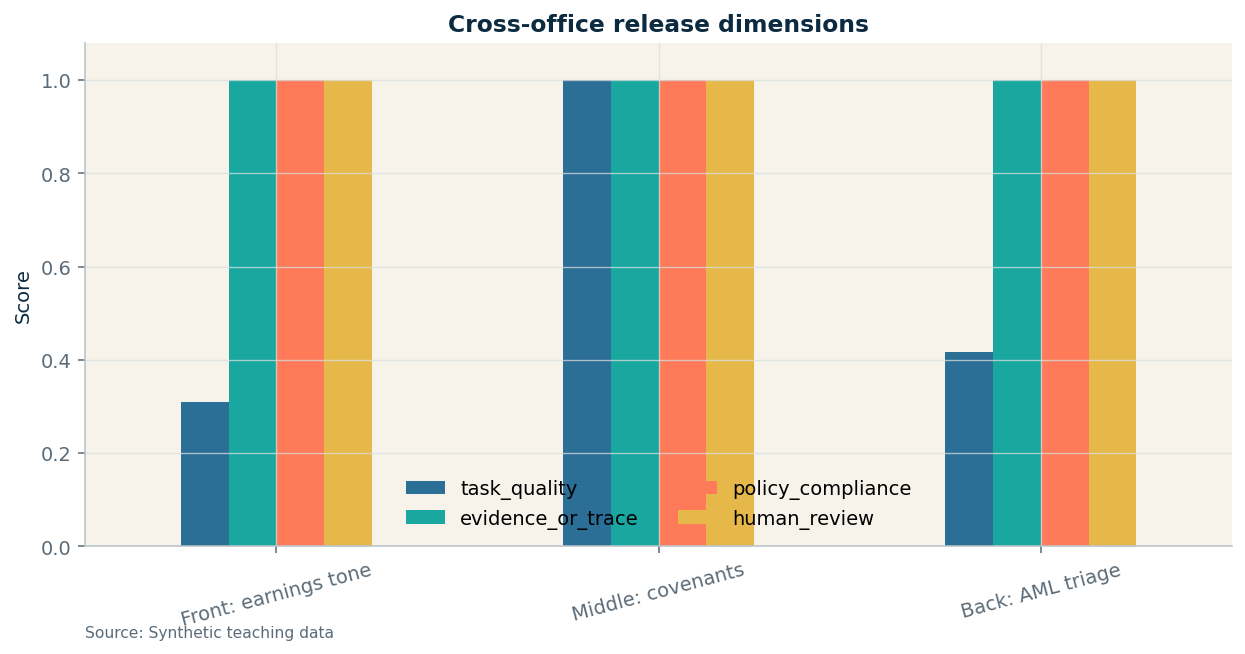

In [7]:
plot_data = scorecard.set_index("application")[
    ["task_quality", "evidence_or_trace", "policy_compliance", "human_review"]
]
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_data.plot(kind="bar", ax=ax, color=[COLORS["blue"], COLORS["teal"], COLORS["coral"], COLORS["gold"]])
ax.set(title="Cross-office release dimensions", ylabel="Score", ylim=(0, 1.08), xlabel="")
ax.tick_params(axis="x", rotation=15)
ax.legend(ncol=2)
finish(ax)
plt.tight_layout()


## 5. Cross-cutting blueprint


In [8]:
blueprint = pd.DataFrame(
    [
        ("Front", "analyst research", "tone + cited metrics", "no direct trade authority", "analyst"),
        ("Middle", "credit monitoring", "terms + recomputed ratios", "breach escalation", "credit officer"),
        ("Back", "investigation triage", "risk score + feature trace", "no auto-closure", "AML investigator"),
    ],
    columns=["office", "decision_supported", "model_artifact", "deterministic_control", "accountable_human"],
)
blueprint


,office,decision_supported,model_artifact,deterministic_control,accountable_human
0,Front,analyst research,tone + cited metrics,no direct trade authority,analyst
1,Middle,credit monitoring,terms + recomputed ratios,breach escalation,credit officer
2,Back,investigation triage,risk score + feature trace,no auto-closure,AML investigator


## Takeaways

- The same model architecture can support workflows with radically different error costs.
- Research outputs remain proposals; breaches and alerts remain review queues.
- Extraction completeness, numerical correctness, recall, and evidence lineage are separate metrics.
- Thresholds are selected on validation data; test metrics are reported with uncertainty.
- A common scorecard should normalize governance dimensions, not erase task differences.

**Challenge:** attach an economic cost to each false negative and false positive, then
reselect the AML threshold under a fixed investigator-capacity budget.
